In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import regionmask
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs

In [2]:
# === Processing functions ===
def adjust_longitude(dataset: xr.Dataset) -> xr.Dataset:
        """Swaps longitude coordinates from range (0, 360) to (-180, 180)
        Args:
            dataset (xr.Dataset): xarray Dataset
        Returns:
            xr.Dataset: xarray Dataset with swapped longitude dimensions
        """
        lon_name = "lon"  # whatever name is in the data

        # Adjust lon values to make sure they are within (-180, 180)
        dataset["_longitude_adjusted"] = xr.where(
            dataset[lon_name] > 180, dataset[lon_name] - 360, dataset[lon_name])
        dataset = (
            dataset.swap_dims({lon_name: "_longitude_adjusted"})
            .sel(**{"_longitude_adjusted": sorted(dataset._longitude_adjusted)})
            .drop_vars(lon_name)
        )

        dataset = dataset.rename({"_longitude_adjusted": lon_name})
        return dataset


# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)


# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da


# === Latitude weighting mean ===
def weighted_mean(da):
    weights = np.cos(np.deg2rad(da.lat))
    weights.name = "weights"
    new_da = da.weighted(weights).mean(("lon", "lat"))
    return new_da

In [3]:
# === Concatenate ensemble members ===
def merge_ensembles(VAR_DIR, VAR, land_mask=False):
    """ land_filter=True allows for the land filter function to remove the ocean """
    ARISE_ens = []
    SSP245_ens = []

    for ens_num in range(1, 11):
        ARISE_ens.append(xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_ARISE_{ens_num:02d}_203501-206912.nc"))
        SSP245_ens.append(xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_SSP245_{ens_num:02d}_202001-206912.nc"))

    arise_da = xr.concat(ARISE_ens, dim=xr.DataArray(np.arange(1, len(ARISE_ens)+1), dims="ensemble", name="ensemble"))
    ssp245_da = xr.concat(SSP245_ens, dim=xr.DataArray(np.arange(1, len(SSP245_ens)+1), dims="ensemble", name="ensemble"))

    if land_mask is True:
        print("Filtering ocean")
        arise_da = land_filter(arise_da)
        ssp245_da = land_filter(ssp245_da)

    return arise_da, ssp245_da

In [10]:
# === Path config ===
TREFHT_DIR = "/glade/work/awells/air_quality/CESM/TREFHT/"
SCENARIOS = ["ARISE", "SSP245"]


# === Main loop ===
arise_t, ssp245_t = merge_ensembles(TREFHT_DIR, "TREFHT", land_mask=False)
arise_t_land, ssp245_t_land = merge_ensembles(TREFHT_DIR, "TREFHT", land_mask=True)

Filtering ocean


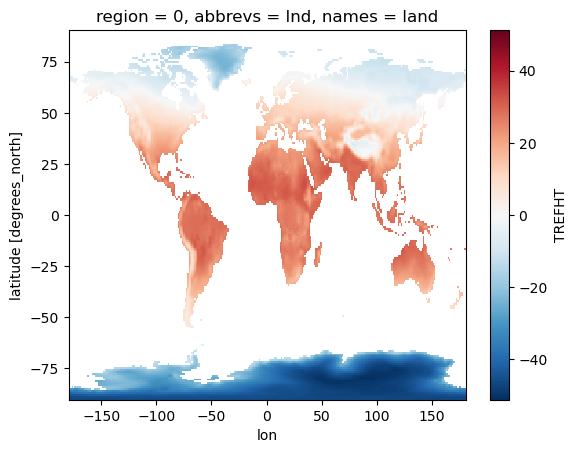

In [8]:
adjust_longitude(arise_t_land.sel(time=slice("2035-01-01", "2035-12-01")).mean(dim=("ensemble", "time"))-273).plot()

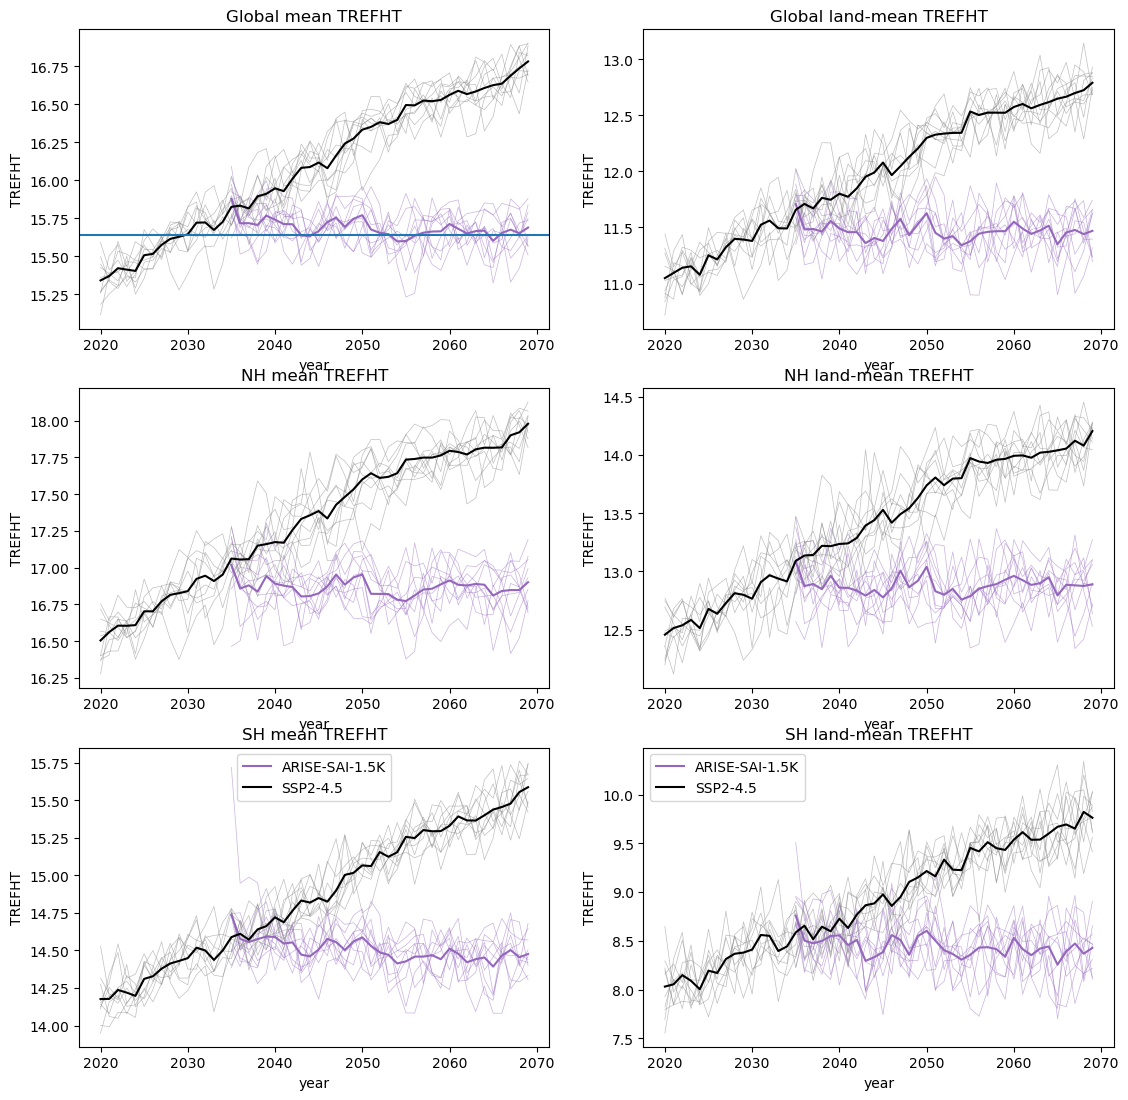

In [11]:
def plot_timeseries(arise, ssp245):
    for ens in range(1, 11):
        arise.sel(ensemble=ens).plot(color="tab:purple", alpha=0.5, linewidth=0.5)
        ssp245.sel(ensemble=ens).plot(color="grey", alpha=0.5, linewidth=0.5)
    arise.mean("ensemble").plot(color="tab:purple", label="ARISE-SAI-1.5K")
    ssp245.mean("ensemble").plot(color="k", label="SSP2-4.5")
    return


plt.figure(figsize=autosize_figure(3, 2))
plt.subplot(3, 2, 1)
arise = weighted_mean(arise_t.groupby("time.year").mean("time"))
ssp245 = weighted_mean(ssp245_t.groupby("time.year").mean(dim="time"))
plot_timeseries(arise-273, ssp245-273)
plt.axhline(15.64)
plt.title("Global mean TREFHT")

plt.subplot(3, 2, 3)
arise = weighted_mean(arise_t.sel(lat=slice(0, 90)).groupby("time.year").mean(dim="time"))
ssp245 = weighted_mean(ssp245_t.sel(lat=slice(0, 90)).groupby("time.year").mean(dim="time"))
plot_timeseries(arise - 273, ssp245 - 273)
plt.title("NH mean TREFHT")

plt.subplot(3, 2, 5)
arise = weighted_mean(arise_t.sel(lat=slice(-90, 0)).groupby("time.year").mean(dim="time"))
ssp245 = weighted_mean(ssp245_t.sel(lat=slice(-90, 0)).groupby("time.year").mean(dim="time"))
plot_timeseries(arise - 273, ssp245 - 273)
plt.title("SH mean TREFHT")
plt.legend()

plt.subplot(3, 2, 2)
arise = weighted_mean(arise_t_land.groupby("time.year").mean("time"))
ssp245 = weighted_mean(ssp245_t_land.groupby("time.year").mean(dim="time"))
plot_timeseries(arise-273, ssp245-273)
plt.title("Global land-mean TREFHT")

plt.subplot(3, 2, 4)
arise = weighted_mean(arise_t_land.sel(lat=slice(0, 90)).groupby("time.year").mean(dim="time"))
ssp245 = weighted_mean(ssp245_t_land.sel(lat=slice(0, 90)).groupby("time.year").mean(dim="time"))
plot_timeseries(arise - 273, ssp245 - 273)
plt.title("NH land-mean TREFHT")

plt.subplot(3, 2, 6)
arise = weighted_mean(arise_t_land.sel(lat=slice(-90, 0)).groupby("time.year").mean(dim="time"))
ssp245 = weighted_mean(ssp245_t_land.sel(lat=slice(-90, 0)).groupby("time.year").mean(dim="time"))
plot_timeseries(arise - 273, ssp245 - 273)
plt.title("SH land-mean TREFHT")
plt.legend()

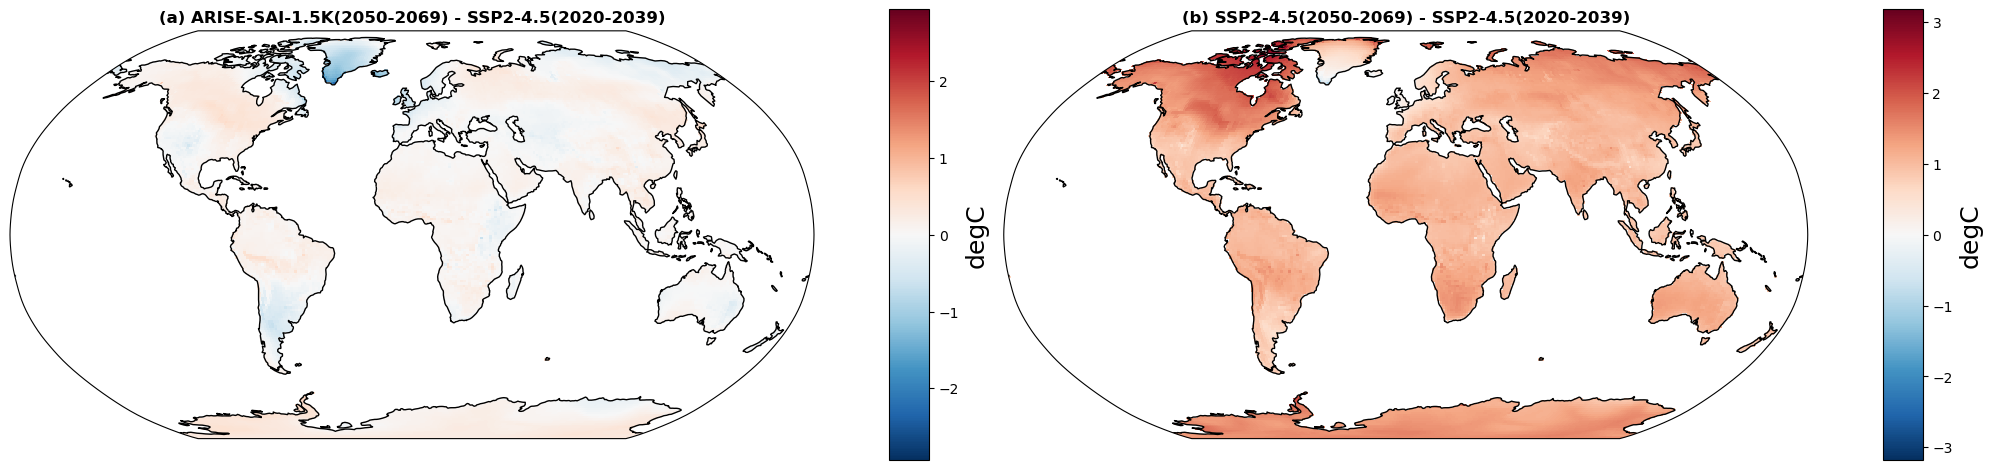

In [7]:
fig = plt.figure(figsize=autosize_figure(2, 2, xscale_factor=1.5))
gs = GridSpec(2, 4, width_ratios=[20, 1, 20, 1]) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

arise = adjust_longitude(arise_t_land.sel(time=slice("2050", "2069")).mean(dim=("ensemble", "time")))
ssp245_early = adjust_longitude(ssp245_t_land.sel(time=slice("2020", "2039")).mean(dim=("ensemble", "time")))
ssp245_late = adjust_longitude(ssp245_t_land.sel(time=slice("2050", "2069")).mean(dim=("ensemble", "time")))

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = (arise - ssp245_early).plot(transform=crs, add_colorbar=False,
                                 subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(a) ARISE-SAI-1.5K(2050-2069) - SSP2-4.5(2020-2039)', fontweight='bold')

# First colorbar
cax = fig.add_subplot(gs[0, 1])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('degC', fontsize=18)

# Second panel
ax = fig.add_subplot(gs[0, 2], projection=projection, frameon=True)
cb = (ssp245_late - ssp245_early).plot(transform=crs, add_colorbar=False,
                                       subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(b) SSP2-4.5(2050-2069) - SSP2-4.5(2020-2039)', fontweight='bold')

# Second colorbar
cax = fig.add_subplot(gs[0, 3])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('degC', fontsize=18)

plt.tight_layout()
